In [23]:
# import libraries
import os
import boto3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
# settings 
MY_BUCKET = "dsan6000-mh2393"
DEST_PREFIX = "wikipedia-hourly/"
IMAGES_DIR = "images"

s3 = boto3.client("s3")

In [25]:
# List the keys of every file in my bucket
# same as hw02-1-download-data
response = s3.list_objects_v2(Bucket=MY_BUCKET, Prefix=DEST_PREFIX)

contents = response["Contents"]

keys = []

for obj in contents:
    key = obj["Key"]
    size = obj["Size"]

    if size > 0:
        keys.append(key)

print(f"Total {len(keys)} parquet files were found")   # should be 24

Total 24 parquet files were found


In [26]:
# Read  hourly files from S3 
dfs = []

for key in keys:
    uri = f"s3://{MY_BUCKET}/{key}"
    hour_df = pd.read_parquet(uri)
    dfs.append(hour_df)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)

(119708, 29)


In [27]:
# check
df[["datetime", "timestamp", "file_ts", "file_ts_str", "type"]].head()
df["type"].value_counts()

type
edit    110896
new       4411
log       4401
Name: count, dtype: int64

In [28]:
# check rows
df[["datetime", "timestamp", "file_ts", "file_ts_str"]].head()

,datetime,timestamp,file_ts,file_ts_str
0,2026-09-01 04:00:02,1788235202,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,1788235202,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,1788235201,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,1788235202,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,1788235203,2026-09-01 04:00:00,20260901_040000


In [29]:
# Convert the hour label to a real datetime 
# make x-axis more clear
df["hour"] = pd.to_datetime(df["file_ts_str"], format="%Y%m%d_%H%M%S")

# Total events per hour
hourly_total = df.groupby("hour").size().reset_index(name="event_count")

print(hourly_total.shape)   # should be (24, 2)
hourly_total.head()

(24, 2)


,hour,event_count
0,2026-09-01 04:00:00,4458
1,2026-09-01 05:00:00,3769
2,2026-09-01 06:00:00,3981
3,2026-09-01 07:00:00,3186
4,2026-09-01 08:00:00,3519


In [30]:
# Events per hour, broken down by type
hourly_by_type = df.groupby(["hour", "type"]).size().reset_index(name="event_count")

print(hourly_by_type.shape)   # should be (72, 3)

(72, 3)


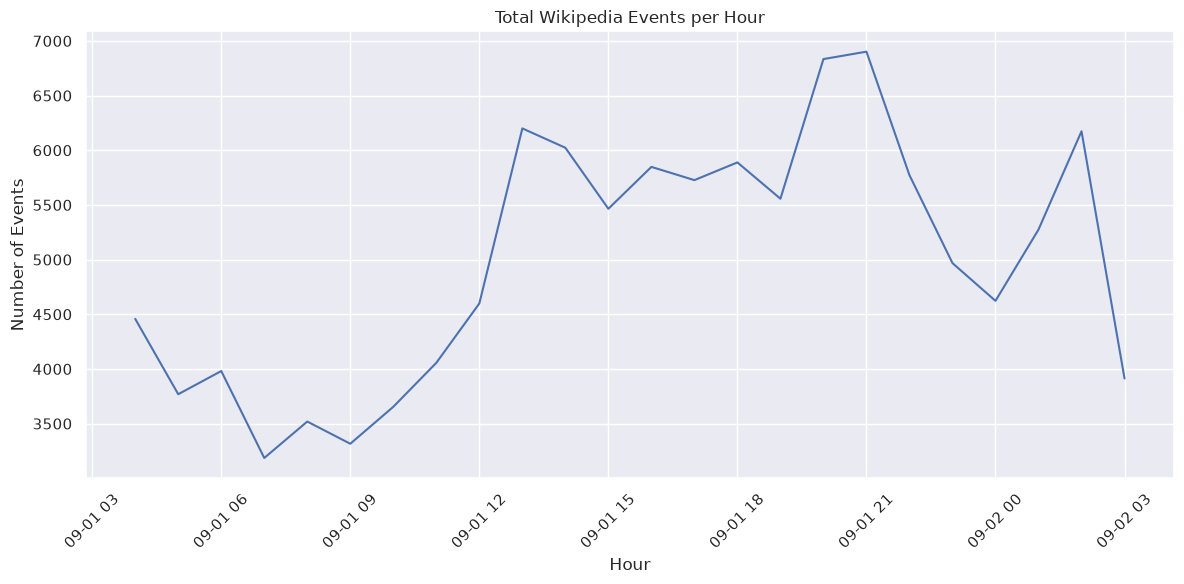

In [31]:
# Make sure the images folder exists
os.makedirs(IMAGES_DIR, exist_ok=True)


plt.figure(figsize=(12, 6))

# plot of total events per hour
sns.lineplot(data=hourly_total, x="hour", y="event_count")


plt.title("Total Wikipedia Events per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()

# save
plt.savefig(os.path.join(IMAGES_DIR, "hourly-events.png"))
plt.savefig(os.path.join(IMAGES_DIR, "hourly-events.svg"))

plt.show()

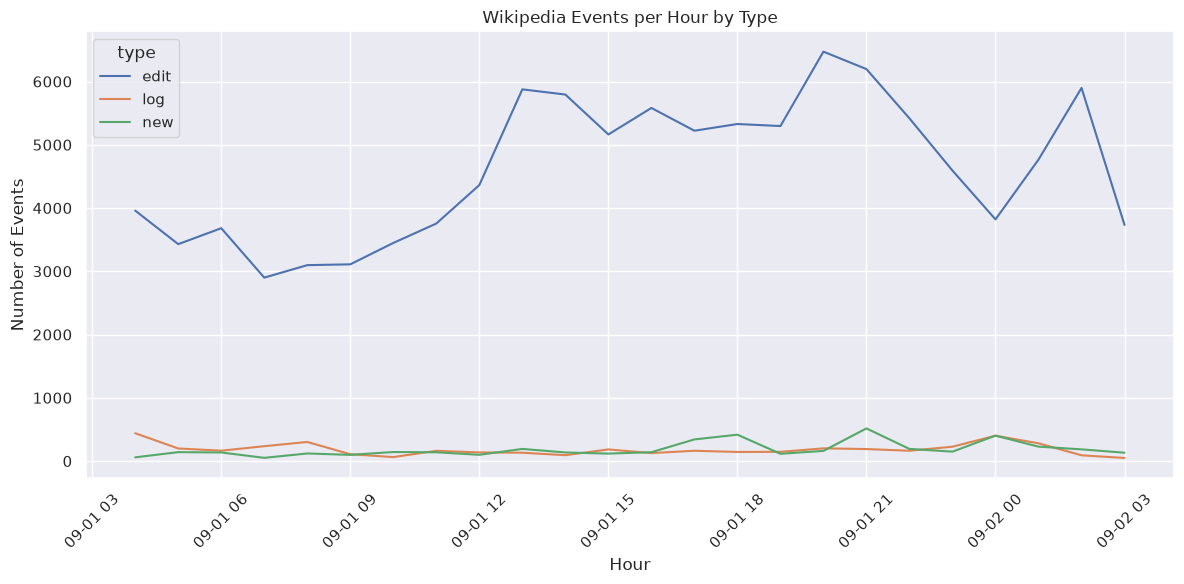

In [32]:
plt.figure(figsize=(12, 6))

# hue splits the data into one line per event type
sns.lineplot(data=hourly_by_type, x="hour", y="event_count", hue="type")

plt.title("Wikipedia Events per Hour by Type")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()

# save
plt.savefig(os.path.join(IMAGES_DIR, "events-by-type.png"))
plt.savefig(os.path.join(IMAGES_DIR, "events-by-type.svg"))

plt.show()